In [4]:
!pip install -q opencv-python matplotlib numpy pillow accelerate bitsandbytes


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
!pip install -q accelerate

In [ ]:
!python -m pip install --upgrade --force-reinstall git+https://github.com/huggingface/transformers

In [ ]:
%%bash
git lfs install
git clone https://huggingface.co/datasets/xiang709/VRSBench

In [ ]:
import zipfile
for z in [ "VRSBench/Annotations_val.zip","VRSBench/Images_val.zip"]:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall("VRSBench_val")

In [1]:
LOCAL_ANNOTATION_DIR = "VRSBench_val/Annotations_val"
LOCAL_IMAGE_DIR = "VRSBench_val/Images_val"

In [2]:
import os
from huggingface_hub import hf_hub_download, login
import sys
import torch
login()

In [3]:
import cv2
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.ops import box_convert
import json
import glob
from transformers.modeling_utils import ModuleUtilsMixin
from PIL import Image, ImageDraw, ImageFont
try:
    from transformers import (
        AutoProcessor, 
        AutoModelForZeroShotObjectDetection,
        Sam3Model, 
        Sam3Processor,
        AutoModelForVision2Seq, 
        BitsAndBytesConfig
    )
    print("Loaded Transformers Classes")
    
except ImportError as e:
    raise ImportError(f"Transformers import failed: {e}. Please run the installation cell again.")

Loaded Transformers Classes


In [27]:
from torch.utils.data import Dataset
from PIL import Image

ANNOTATION_DIR = "VRSBench_val/Annotations_val"
IMAGE_DIR = "VRSBench_val/Images_val"
OUTPUT_DIR = "eval_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

class VRSBenchDataset:
    def __init__(self, anno_dir, img_dir, max_samples=5):
        self.files = glob.glob(os.path.join(anno_dir, "*.json"))[:max_samples]
        self.img_dir = img_dir
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        with open(self.files[idx], 'r') as f: data = json.load(f)
        img_name = data.get('image') or os.path.basename(self.files[idx]).replace('.json','.png')
        
        # Fix extensions logic
        img_path = os.path.join(self.img_dir, img_name)
        if not os.path.exists(img_path): 
            alt_path = img_path.replace('.png','.jpg')
            if os.path.exists(alt_path): img_path = alt_path
        
        objs = data.get('objects', [])
        return {"image_path": img_path, "image_id": img_name, "label": objs[0]['obj_cls'] if objs else None}

dataset = VRSBenchDataset(ANNOTATION_DIR, IMAGE_DIR,10)

In [5]:
import torch
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import re

from transformers import (
    AutoProcessor, 
    AutoModelForVision2Seq,
    Sam3Model,      
    Sam3Processor
)

class IntegratedVLMGrounding:
    def __init__(self, device="cuda"):
        self.device = device
        print(f"--- Initializing Integrated Pipeline on {torch.cuda.get_device_name(0)} ---")
        
        print("Loading Qwen2.5-VL-3B (bfloat16)...")
        self.qwen_processor = AutoProcessor.from_pretrained(
            "Qwen/Qwen2.5-VL-3B-Instruct", 
            trust_remote_code=True
        )
        
        self.qwen_model = AutoModelForVision2Seq.from_pretrained(
            "Qwen/Qwen2.5-VL-3B-Instruct",
            device_map="auto",
            trust_remote_code=True,
            torch_dtype=torch.bfloat16  # Optimized for A6000
        )

        print("Loading SAM 3...")
        try:
            self.sam_processor = Sam3Processor.from_pretrained("facebook/sam3")
            self.sam_model = Sam3Model.from_pretrained("facebook/sam3").to(self.device)
        except OSError:
            print("Warning: 'facebook/sam3' not found on HF. Please ensure you have access or check the model ID.")
            raise
        
        print("Pipeline Ready.")

    def get_obb_from_mask(self, mask):
        mask_np = mask.cpu().numpy().astype(np.uint8)
        contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) == 0:
            return None
        largest_contour = max(contours, key=cv2.contourArea)
        # minAreaRect returns ((center_x, center_y), (width, height), angle)
        obb = cv2.minAreaRect(largest_contour) 
        return obb

    def annotate_image_with_boxes(self, image, obbs):

        annotated_img = image.copy()
        draw = ImageDraw.Draw(annotated_img)

        try:
            font = ImageFont.truetype("arial.ttf", size=24)
        except:
            font = ImageFont.load_default()

        valid_candidates = {} # Map ID -> OBB
        
        for idx, obb in enumerate(obbs,start=1):
            if obb is None: continue

            box_points = cv2.boxPoints(obb)
            box_points = np.int32(box_points)
            polygon = [tuple(pt) for pt in box_points]

            draw.polygon(polygon, outline="red", width=4)

            center_x, center_y = obb[0]
            text = str(idx)
            bbox = draw.textbbox((center_x, center_y), text, font=font)
            # Expand background slightly
            draw.rectangle((bbox[0]-2, bbox[1]-2, bbox[2]+2, bbox[3]+2), fill="white")
            draw.text((center_x, center_y), text, fill="black", font=font, anchor="mm")
            
            valid_candidates[idx] = obb
            
        return annotated_img, valid_candidates

    def ask_qwen(self, image, prompt, max_tokens=128):
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt},
                ],
            }
        ]
        
        text_prompt = self.qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        
        inputs = self.qwen_processor(
            text=[text_prompt], 
            images=[image], 
            return_tensors="pt", 
            padding=True
        )
        
        inputs = inputs.to(self.qwen_model.device)
        
        output_ids = self.qwen_model.generate(**inputs, max_new_tokens=max_tokens)
 
        generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, output_ids)]
        output_text = self.qwen_processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)[0]
        return output_text

    def process_query(self, image_path, complex_query):
        try:
            original_image = Image.open(image_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return None, None

        extraction_prompt = (
            f"Identify the single main object category being referred to in this query: '{complex_query}'. "
            "For example, if the query is 'pick the red car', output 'car'. "
            "If the query is 'find the plane on the far left', output 'plane'. "
            "Output ONLY the single word category."
        )
        target_class = self.ask_qwen(original_image, extraction_prompt, max_tokens=10).strip().lower()
        target_class = re.sub(r'[^\w\s]', '', target_class).strip()
        print(f"1. Extracted Target Class: '{target_class}'")

        print(f"2. Running SAM 3 to segment all '{target_class}' instances...")
        inputs = self.sam_processor(
            images=original_image, 
            text=target_class, 
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():
            outputs = self.sam_model(**inputs)

        results = self.sam_processor.post_process_instance_segmentation(
            outputs, 
            threshold=0.4, 
            target_sizes=[(original_image.height, original_image.width)]
        )[0]

        masks = results["masks"] # [N, H, W]
        
        if len(masks) == 0:
            print(f"   No objects of type '{target_class}' found.")
            return None, original_image


        obbs = [self.get_obb_from_mask(m) for m in masks]
        
        annotated_image, candidates = self.annotate_image_with_boxes(original_image, obbs)

        annotated_image.save("debug_candidates.jpg")
        print(f"   Found {len(candidates)} candidates. Annotated image saved to 'debug_candidates.jpg'.")

        selection_prompt = (
            f"The user wants to: '{complex_query}'. "
            f"I have detected multiple {target_class}s and marked them with red boxes and unique numeric IDs. "
            "Based on the visual evidence, which ID number best corresponds to the user's request? "
            "Output ONLY the ID number."
        )
        
        final_answer = self.ask_qwen(annotated_image, selection_prompt, max_tokens=10)
        print(f"3. Qwen Selection Response: {final_answer}")
        
        match = re.search(r'\d+', final_answer)
        if match:
            selected_id = int(match.group())
            if selected_id in candidates:
                print(f"   SUCCESS: Selected Object ID {selected_id}")
                return candidates[selected_id], annotated_image
            else:
                print(f"   FAIL: Qwen predicted ID {selected_id}, but it is not in the valid candidate list.")
        else:
            print("FAIL: Could not parse a valid ID number from Qwen's response.")
            
        return None, annotated_image

pipeline = IntegratedVLMGrounding(device="cuda")

--- Initializing Integrated Pipeline on NVIDIA RTX A6000 ---
Loading Qwen2.5-VL-3B (bfloat16)...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/transformers/models/auto/modeling_auto.py:2230: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Loading SAM 3...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [23]:
class IntegratedVLMGroundingThinking:
    def __init__(self, device="cuda"):
        self.device = device
        print(f"Initializing Qwen3-VL 4B Thinking Pipeline on {torch.cuda.get_device_name(0)}")
        self.qwen_model_id = "Qwen/Qwen3-VL-4B-Thinking"
        
        try:
            self.qwen_processor = AutoProcessor.from_pretrained(
                self.qwen_model_id, 
                trust_remote_code=True
            )
            self.qwen_model = AutoModelForVision2Seq.from_pretrained(
                self.qwen_model_id,
                device_map="auto",
                trust_remote_code=True,
                torch_dtype=torch.bfloat16
            )
            
        except Exception as e:
            print(f"\n Error loading Qwen3: {e}")
            print("Qwen3-VL requires the latest transformers. Try: pip install git+https://github.com/huggingface/transformers")
            raise e

        print("Loading SAM 3...")
        self.sam_processor = Sam3Processor.from_pretrained("facebook/sam3")
        self.sam_model = Sam3Model.from_pretrained("facebook/sam3").to(self.device)
        
        print("Pipeline Ready.")

    def get_obb_from_mask(self, mask):
        mask_np = mask.cpu().numpy().astype(np.uint8)
        contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) == 0:
            return None
        largest_contour = max(contours, key=cv2.contourArea)
        obb = cv2.minAreaRect(largest_contour) 
        return obb

    def annotate_image_with_boxes(self, image, obbs):
        annotated_img = image.copy()
        draw = ImageDraw.Draw(annotated_img)
        
        try:
            font = ImageFont.truetype("arial.ttf", size=24)
        except:
            font = ImageFont.load_default()

        valid_candidates = {} 
        
        for idx, obb in enumerate(obbs, start=1):
            if obb is None: continue
            
            # Draw Box
            box_points = cv2.boxPoints(obb)
            box_points = np.int32(box_points)
            polygon = [tuple(pt) for pt in box_points]
            draw.polygon(polygon, outline="red", width=4)
            
            # Draw Label with background
            center_x, center_y = obb[0]
            text = str(idx)
            bbox = draw.textbbox((center_x, center_y), text, font=font)
            draw.rectangle((bbox[0]-4, bbox[1]-4, bbox[2]+4, bbox[3]+4), fill="white")
            draw.text((center_x, center_y), text, fill="black", font=font, anchor="mm")
            
            valid_candidates[idx] = obb
            
        return annotated_img, valid_candidates

    def ask_qwen(self, image, prompt, max_tokens=2048):
        """
        Queries Qwen. Increased max_tokens to support 'Thinking' process.
        """
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt},
                ],
            }
        ]
        
        text_prompt = self.qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        
        inputs = self.qwen_processor(
            text=[text_prompt], 
            images=[image], 
            return_tensors="pt", 
            padding=True
        ).to(self.qwen_model.device)
        
        output_ids = self.qwen_model.generate(**inputs, max_new_tokens=max_tokens)
        
        # Decode
        generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, output_ids)]
        output_text = self.qwen_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        return output_text

    def parse_thinking_output(self, text):
        """
        Parses Qwen3-Thinking output. 
        It separates the <think> block from the final answer to avoid false positives.
        """
        # Remove the thinking block to isolate the final answer
        # This regex matches <think>...content...</think> (dotall allows matching newlines)
        clean_text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()
        
        # If the model didn't use tags (rare) or failed, verify if clean_text is empty
        if not clean_text:
            print("Warning: No text found after <think> block. Using full text.")
            clean_text = text
            
        return clean_text

    def process_query(self, image_path, complex_query):
        try:
            original_image = Image.open(image_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image: {e}")
            return None, None

        extraction_prompt = (
            f"Analyze the query: '{complex_query}'. "
            "Identify the single main object category I need to find. "
            "Output ONLY the category name (e.g., 'car', 'plane', 'ship')."
        )
        # Increased tokens here too, just in case
        raw_class_response = self.ask_qwen(original_image, extraction_prompt, max_tokens=512)
        final_class_text = self.parse_thinking_output(raw_class_response)
        
        # Clean up punctuation
        target_class = re.sub(r'[^\w\s]', '', final_class_text).strip().lower().split('\n')[-1]
        print(f"1. Extracted Class: '{target_class}' (from output: {final_class_text})")

        print(f"2. Running SAM 3 for '{target_class}'...")
        inputs = self.sam_processor(
            images=original_image, 
            text=target_class, 
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():
            outputs = self.sam_model(**inputs)

        results = self.sam_processor.post_process_instance_segmentation(
            outputs, 
            threshold=0.3, 
            target_sizes=[(original_image.height, original_image.width)]
        )[0]

        masks = results["masks"]
        if len(masks) == 0:
            print(f"   No objects found.")
            return None, original_image

        obbs = [self.get_obb_from_mask(m) for m in masks]
        

        annotated_image, candidates = self.annotate_image_with_boxes(original_image, obbs)
        annotated_image.save("debug_candidates.jpg")
        print(f"   Found {len(candidates)} candidates.")

        # Qwen3-Thinking excels here. We give it ample tokens to reason about coordinates.
        selection_prompt = (
            f"The user wants: '{complex_query}'. "
            f"I have detected {len(candidates)} {target_class}s, marked with red boxes and ID numbers. "
            "Think step-by-step about which ID matches the user's spatial description. "
            "Finally, output ONLY the numeric ID."
        )
        
        # Huge max_tokens allowed for deep thinking
        raw_selection_response = self.ask_qwen(annotated_image, selection_prompt, max_tokens=2048)
        
        # Extract final answer from after the </think> tag
        final_answer_text = self.parse_thinking_output(raw_selection_response)
        
        print(f"3. Full Response: {raw_selection_response[:100]}...")
        print(f"   Final Answer Part: {final_answer_text}")

        # Parse ID
        match = re.search(r'\d+', final_answer_text)
        if match:
            selected_id = int(match.group())
            if selected_id in candidates:
                print(f"   SUCCESS: Selected ID {selected_id}")
                return candidates[selected_id], annotated_image
            else:
                print(f"   FAIL: ID {selected_id} not in candidates.")
        else:
            print("   FAIL: No ID found in final answer.")
            
        return None, annotated_image


pipeline_thinking = IntegratedVLMGroundingThinking(device="cuda")

Initializing Qwen3-VL 4B Thinking Pipeline on NVIDIA RTX A6000


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Loading SAM 3...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [28]:
dataset[5]['image_path']
dataset[5]['label']

'airplane'

1. Extracted Class: 'plane' (from output: Got it, let's see. The task is to find the airplane farthest from all others. First, I need to identify all the airplanes in the image. Looking at the image, there are several planes. Let's list them:

- On the left side, there's a plane at the top left corner (maybe the one with wings visible).
- Then another plane near the center left, maybe the one with the blue and white.
- At the bottom left, there are a couple more planes, like two or three.

Wait, the question is asking for the category of the main object. The query says "identify the single main object category I need to find". The main object here is the airplane, since we're talking about which airplane is farthest. So the category is 'plane'.
</think>

plane)
2. Running SAM 3 for 'plane'...
   Found 8 candidates.
3. Full Response: So, let's try to figure out which airplane is the farthest from all the others. First, I need to vis...
   Final Answer Part: So, let's try to figure out w

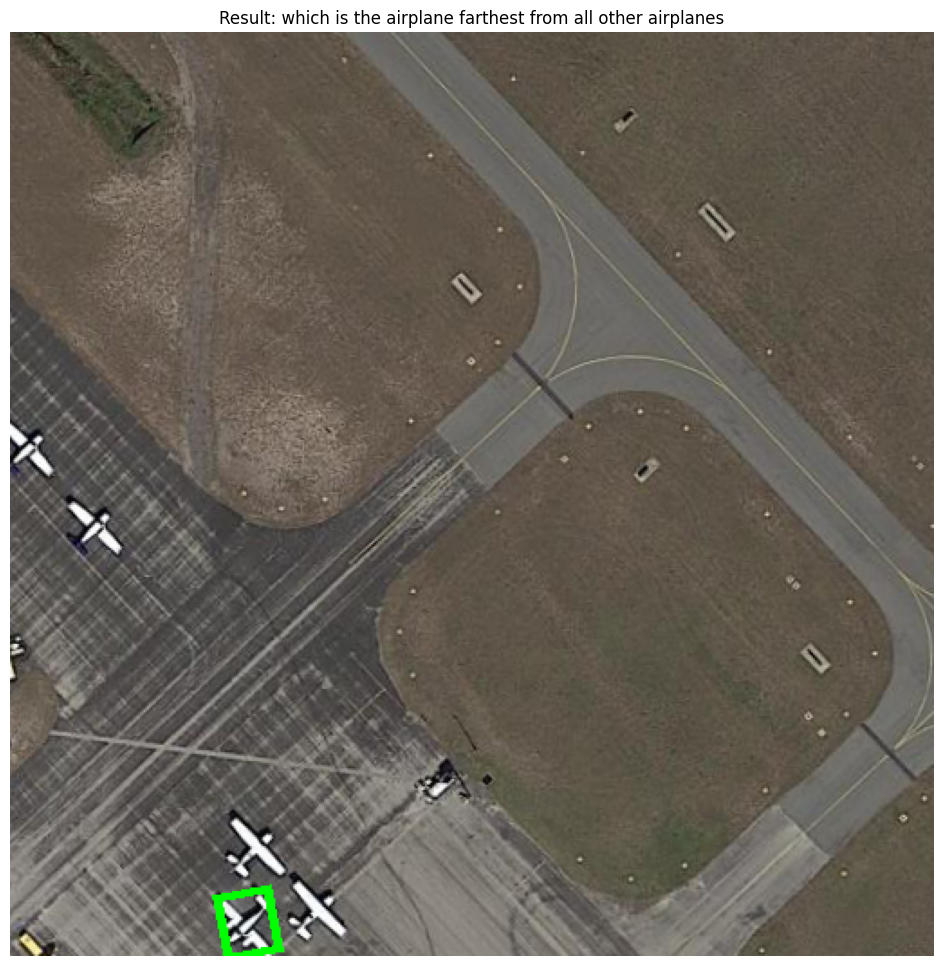

In [29]:
test_img_path = dataset[5]['image_path'] 
user_query = "which is the airplane farthest from all other airplanes"
best_obb, ann_img = pipeline_thinking.process_query(test_img_path, user_query)

if best_obb:
    final_img = Image.open(test_img_path).convert("RGB")
    draw = ImageDraw.Draw(final_img)

    box_points = cv2.boxPoints(best_obb)
    box_points = np.int32(box_points)
    draw.polygon([tuple(pt) for pt in box_points], outline="#00FF00", width=5)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(final_img)
    plt.title(f"Result: {user_query}")
    plt.axis("off")
    plt.show()
